# Bearing Fault Model Training

This notebook trains the Phase 1 bearing-fault classifier for the hackathon demo.

Pipeline: CWRU drive-end vibration signals -> rolling windows -> statistical and FFT features -> Random Forest classifier -> exported artifacts for edge inference.

## 1. Imports And Configuration

Use the three selected CWRU records from Phase 2: Healthy, Warning, and Critical. The model is trained on fixed-size windows so inference can run on live chunks later.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "backend"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

BACKEND_DIR = PROJECT_ROOT / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from app.cwru_dataset import SELECTED_CWRU_FILES, load_drive_end_signal
from app.features import FEATURE_COLUMNS, extract_features, window_signal

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 2048
STEP_SIZE = 1024
RANDOM_STATE = 42

print(PROJECT_ROOT)
print(FEATURE_COLUMNS)

Matplotlib is building the font cache; this may take a moment.


/Users/kisna/Developer/Learning/Sentry - tata innovet
['rms', 'std', 'kurtosis', 'dominant_freq_hz', 'spectral_energy']


## 2. Load Raw CWRU Signals

Each file is loaded through the Phase 2 dataset manifest. We use the drive-end accelerometer signal because it is closest to the bearing and is a standard CWRU classification input.

In [2]:
signals = []

for selection in SELECTED_CWRU_FILES:
    signal = load_drive_end_signal(selection)
    signals.append((selection, signal))
    print(
        f"{selection.label:8s} | {selection.filename:30s} | "
        f"key={selection.signal_key:12s} | samples={signal.size:,} | "
        f"mean={signal.mean():.6f} | std={signal.std():.6f}"
    )

Healthy  | 97_Normal_0hp_1797rpm.mat      | key=X097_DE_time | samples=243,938 | mean=0.012558 | std=0.072687
Warning  | 105_IR007_0hp_1797rpm.mat      | key=X105_DE_time | samples=121,265 | mean=0.013444 | std=0.291216
Critical | 209_IR021_0hp_1797rpm.mat      | key=X209_DE_time | samples=122,136 | mean=0.014146 | std=0.525183


## 3. Inspect Signal Shape And Sample Rate

The selected files use 12 kHz drive-end signals at the same 0 HP load condition. The standard deviation already shows a useful severity progression for the demo.

In [3]:
signal_summary = pd.DataFrame(
    [
        {
            "label": selection.label,
            "filename": selection.filename,
            "sample_rate_hz": selection.sample_rate_hz,
            "rpm": selection.rpm,
            "fault_type": selection.fault_type,
            "fault_size_inches": selection.fault_size_inches,
            "samples": signal.size,
            "duration_seconds": signal.size / selection.sample_rate_hz,
            "mean": signal.mean(),
            "std": signal.std(),
        }
        for selection, signal in signals
    ]
)

signal_summary

,label,filename,sample_rate_hz,rpm,fault_type,fault_size_inches,samples,duration_seconds,mean,std
0,Healthy,97_Normal_0hp_1797rpm.mat,12000,1797,none,NaN,243938,20.328167,0.012558,0.072687
1,Warning,105_IR007_0hp_1797rpm.mat,12000,1797,inner_race,0.007,121265,10.105417,0.013444,0.291216
2,Critical,209_IR021_0hp_1797rpm.mat,12000,1797,inner_race,0.021,122136,10.178000,0.014146,0.525183


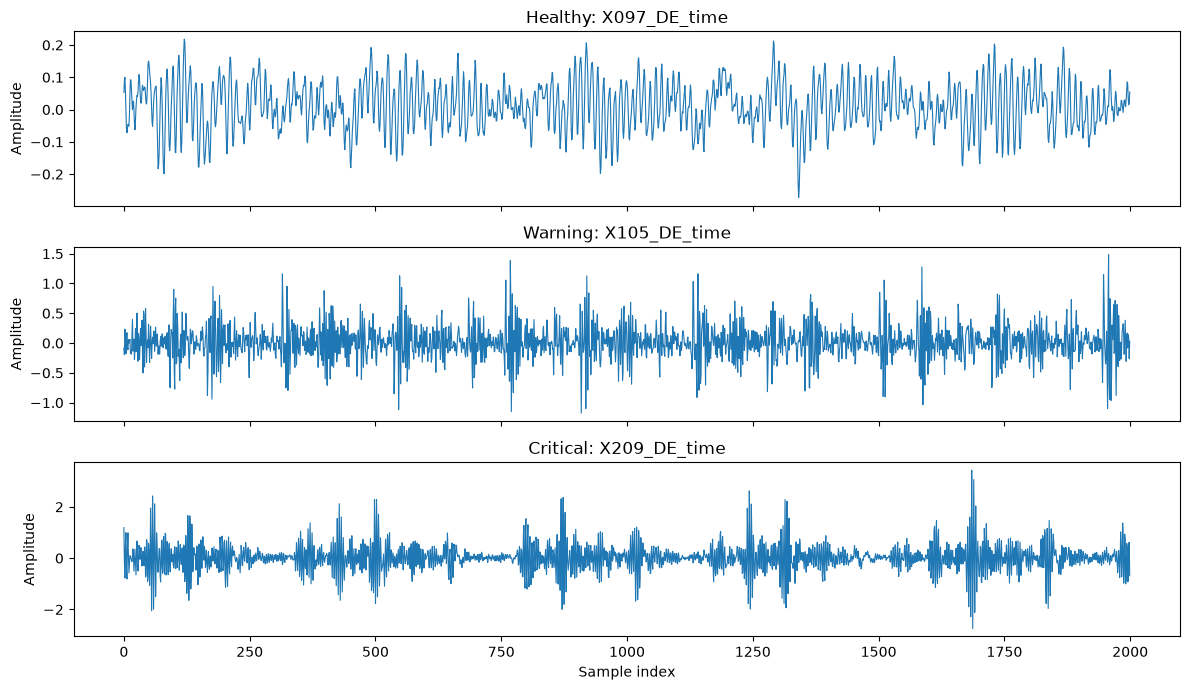

In [4]:
preview_samples = 2000
fig, axes = plt.subplots(len(signals), 1, figsize=(12, 7), sharex=True)

for axis, (selection, signal) in zip(axes, signals):
    axis.plot(signal[:preview_samples], linewidth=0.8)
    axis.set_title(f"{selection.label}: {selection.signal_key}")
    axis.set_ylabel("Amplitude")

axes[-1].set_xlabel("Sample index")
plt.tight_layout()

## 4. Segment Signals Into Rolling Windows

Use 2048-sample windows with 50% overlap. At 12 kHz this is about 0.17 seconds per window, which gives enough training examples while staying responsive for live inference.

In [5]:
window_counts = []

for selection, signal in signals:
    windows = window_signal(signal, WINDOW_SIZE, STEP_SIZE)
    window_counts.append(
        {
            "label": selection.label,
            "windows": len(windows),
            "window_size": WINDOW_SIZE,
            "step_size": STEP_SIZE,
            "window_seconds": WINDOW_SIZE / selection.sample_rate_hz,
        }
    )

pd.DataFrame(window_counts)

,label,windows,window_size,step_size,window_seconds
0,Healthy,237,2048,1024,0.170667
1,Warning,117,2048,1024,0.170667
2,Critical,118,2048,1024,0.170667


## 5. Extract Features

For each window, extract RMS, standard deviation, kurtosis, dominant frequency, and spectral energy. These are fast to compute and easy to explain in a demo Q&A.

In [6]:
records = []

for selection, signal in signals:
    windows = window_signal(signal, WINDOW_SIZE, STEP_SIZE)
    for window_index, window in enumerate(windows):
        feature_values = extract_features(window, selection.sample_rate_hz)
        records.append(
            {
                "label": selection.label,
                "severity": selection.severity,
                "fault_type": selection.fault_type,
                "fault_size_inches": selection.fault_size_inches,
                "source_file": selection.filename,
                "signal_key": selection.signal_key,
                "sample_rate_hz": selection.sample_rate_hz,
                "window_index": window_index,
                **feature_values,
            }
        )

features_df = pd.DataFrame.from_records(records)
features_path = DATA_PROCESSED_DIR / "features.csv"
features_df.to_csv(features_path, index=False)

print(f"Saved {len(features_df):,} rows to {features_path}")
features_df.head()

Saved 472 rows to /Users/kisna/Developer/Learning/Sentry - tata innovet/data/processed/features.csv


,label,severity,fault_type,fault_size_inches,source_file,signal_key,sample_rate_hz,window_index,rms,std,kurtosis,dominant_freq_hz,spectral_energy
0,Healthy,normal,none,NaN,97_Normal_0hp_1797rpm.mat,X097_DE_time,12000,0,0.073256,0.072266,2.957000,1037.109375,5.347727
1,Healthy,normal,none,NaN,97_Normal_0hp_1797rpm.mat,X097_DE_time,12000,1,0.074507,0.073344,2.886312,1037.109375,5.508378
2,Healthy,normal,none,NaN,97_Normal_0hp_1797rpm.mat,X097_DE_time,12000,2,0.079035,0.077993,2.817904,1037.109375,6.228937
3,Healthy,normal,none,NaN,97_Normal_0hp_1797rpm.mat,X097_DE_time,12000,3,0.077916,0.076964,2.851910,1037.109375,6.065558
4,Healthy,normal,none,NaN,97_Normal_0hp_1797rpm.mat,X097_DE_time,12000,4,0.074338,0.073370,2.780633,1037.109375,5.512283


In [7]:
features_df.groupby("label")[FEATURE_COLUMNS].agg(["mean", "std"]).round(4)

rms             std         kurtosis         dominant_freq_hz  \
            mean     std    mean     std     mean     std             mean   
label                                                                        
Critical  0.5249  0.0166  0.5247  0.0166   7.4077  0.9590        2898.0072   
Healthy   0.0737  0.0020  0.0726  0.0020   2.7585  0.1286        1037.1094   
Warning   0.2914  0.0032  0.2911  0.0033   5.4059  0.2786        3571.0637   

                   spectral_energy           
               std            mean      std  
label                                        
Critical   71.3204        282.1870  17.9365  
Healthy     0.0000          5.4075   0.2958  
Warning   126.2020         86.7606   1.9396

## 6. Build Labeled Feature Table And Split Data

The classifier predicts three demo states: Healthy, Warning, and Critical. A stratified train/test split preserves the class balance in the validation set.

In [8]:
X = features_df[FEATURE_COLUMNS]
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(y_test.value_counts().sort_index())

Training rows: 354
Test rows: 118
label
Critical    30
Healthy     59
Warning     29
Name: count, dtype: int64


## 7. Train Random Forest Classifier

Random Forest is a good fit for this prototype: fast training, strong baseline performance on tabular features, and explainable enough for judges.

In [9]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 8. Evaluate Model

The held-out validation score is the accuracy number to quote in the demo/presentation. The confusion matrix is also saved to the report artifact.

In [10]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)
labels = list(model.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(f"Accuracy: {accuracy:.4f}")
print(report)

Accuracy: 1.0000
              precision    recall  f1-score   support

    Critical     1.0000    1.0000    1.0000        30
     Healthy     1.0000    1.0000    1.0000        59
     Warning     1.0000    1.0000    1.0000        29

    accuracy                         1.0000       118
   macro avg     1.0000    1.0000    1.0000       118
weighted avg     1.0000    1.0000    1.0000       118



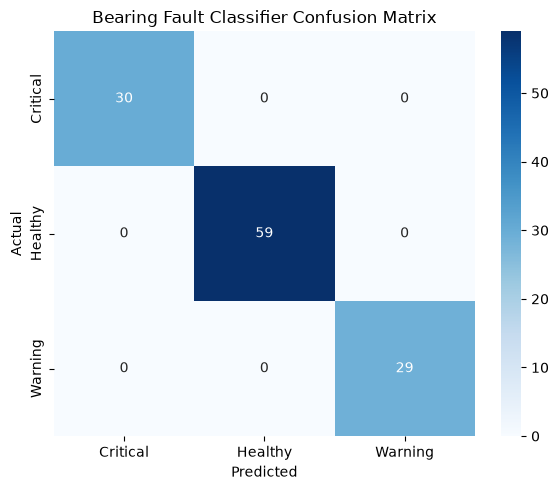

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bearing Fault Classifier Confusion Matrix")
plt.tight_layout()

In [12]:
feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,rms,0.269080
1,std,0.232041
4,spectral_energy,0.219933
3,dominant_freq_hz,0.144392
2,kurtosis,0.134554


## 9. Export Model Artifacts

Save the trained model, feature baseline from healthy windows, and a text report. The backend will load these directly for edge inference.

In [13]:
healthy_features = features_df.loc[features_df["label"] == "Healthy", FEATURE_COLUMNS]
feature_baseline = {
    feature: {
        "mean": float(healthy_features[feature].mean()),
        "std": float(healthy_features[feature].std()),
        "p05": float(healthy_features[feature].quantile(0.05)),
        "p95": float(healthy_features[feature].quantile(0.95)),
    }
    for feature in FEATURE_COLUMNS
}

model_payload = {
    "model": model,
    "feature_columns": FEATURE_COLUMNS,
    "classes": labels,
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "sample_rate_hz": 12_000,
}

model_path = MODELS_DIR / "bearing_rf_model.joblib"
baseline_path = MODELS_DIR / "feature_baseline.json"
report_path = OUTPUTS_DIR / "model_report.txt"

joblib.dump(model_payload, model_path)
baseline_path.write_text(json.dumps(feature_baseline, indent=2), encoding="utf-8")

report_text = "\n".join(
    [
        "Bearing Fault Random Forest Report",
        "==================================",
        f"Dataset rows: {len(features_df)}",
        f"Window size: {WINDOW_SIZE}",
        f"Step size: {STEP_SIZE}",
        f"Feature columns: {', '.join(FEATURE_COLUMNS)}",
        f"Accuracy: {accuracy:.4f}",
        "",
        "Classification report:",
        report,
        "Confusion matrix labels: " + ", ".join(labels),
        np.array2string(cm),
        "",
        "Feature importance:",
        feature_importance.to_string(index=False),
    ]
)
report_path.write_text(report_text, encoding="utf-8")

print(f"Saved model: {model_path}")
print(f"Saved baseline: {baseline_path}")
print(f"Saved report: {report_path}")
print(f"Saved features: {features_path}")

Saved model: /Users/kisna/Developer/Learning/Sentry - tata innovet/models/bearing_rf_model.joblib
Saved baseline: /Users/kisna/Developer/Learning/Sentry - tata innovet/models/feature_baseline.json
Saved report: /Users/kisna/Developer/Learning/Sentry - tata innovet/outputs/model_report.txt
Saved features: /Users/kisna/Developer/Learning/Sentry - tata innovet/data/processed/features.csv


In [14]:
loaded_payload = joblib.load(model_path)
loaded_model = loaded_payload["model"]
loaded_prediction = loaded_model.predict(X_test.iloc[[0]])[0]
loaded_confidence = loaded_model.predict_proba(X_test.iloc[[0]]).max()

print(f"Loaded model prediction check: {loaded_prediction} ({loaded_confidence:.3f})")

Loaded model prediction check: Warning (1.000)


## Result

The notebook now creates the training feature table, validates a Random Forest classifier, and exports the artifacts needed for real-time edge inference.